In [1]:
import sys
print(sys.version)

3.9.6 (default, Nov 11 2024, 03:15:39) 
[Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:
pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 MB 14.1 MB/s  0:00:18m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 13.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 19.8 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 18.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 21.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 18.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 19.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.1 MB/s  0:00:00
Using cached rich-15.0.0-py3-none-any.whl (310 kB)
Us

In [7]:
pip install yfinance tensorflow scikit-learn matplotlib pandas numpy

Defaulting to user installation because normal site-packages is not writeable
  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.0.5-py3-none-any.whl.metadata (8.6 kB)
INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 1.8 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 3.4 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 5.7 MB/s  0:00:02 eta 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 7.5 MB/s  0:00:00 eta 0:00:01
Using cached multitasking-0.0.13-py3-none-any.whl (

In [9]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [8]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

/Users/macbook/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2026-05-09 21:02:16.520838: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
apple = yf.download("AAPL", start="1981-01-01")

# Fix MultiIndex issue
apple.columns = apple.columns.get_level_values(0)

print(apple.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open    Volume
Date                                                        
1981-01-02  0.117957  0.118812  0.117957  0.117957  21660800
1981-01-05  0.115393  0.115821  0.115393  0.115821  35728000
1981-01-06  0.110264  0.110692  0.110264  0.110692  45158400
1981-01-07  0.105563  0.105991  0.105563  0.105991  55686400
1981-01-08  0.103427  0.103854  0.103427  0.103854  39827200


In [11]:
data = apple[["Close"]]

In [12]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.00027396]
 [0.00026522]
 [0.00024773]
 [0.0002317 ]
 [0.00022442]]


In [13]:
x = []
y = []

for i in range(60, len(scaled_data)):
    x.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

x = np.array(x)
y = np.array(y)

In [14]:
x = np.reshape(x, (x.shape[0], x.shape[1], 1))

print(x.shape)

(11370, 60, 1)


In [15]:
split = int(len(x) * 0.8)

x_train = x[:split]
y_train = y[:split]

x_test = x[split:]
y_test = y[split:]

In [16]:
model = Sequential()

model.add(LSTM(units=64, return_sequences=True,
               input_shape=(x_train.shape[1], 1)))

model.add(Dropout(0.2))

model.add(LSTM(units=64))

model.add(Dropout(0.2))

model.add(Dense(1))

/Users/macbook/Library/Python/3.9/lib/python/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 25s 75ms/step - loss: 5.5338e-05 - val_loss: 0.0011
Epoch 2/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 36s 59ms/step - loss: 7.8426e-06 - val_loss: 0.0021
Epoch 3/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - loss: 7.0997e-06 - val_loss: 0.0021
Epoch 4/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - loss: 8.2340e-06 - val_loss: 4.0358e-04
Epoch 5/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - loss: 6.9739e-06 - val_loss: 4.8834e-04
Epoch 6/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - loss: 6.5405e-06 - val_loss: 3.6297e-04
Epoch 7/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - loss: 6.3043e-06 - val_loss: 5.8684e-04
Epoch 8/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 6.5030e-06 - val_loss: 0.0026
Epoch 9/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - loss: 8.5905e-06 - val_loss: 4.5824e-04
Epoch 10/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 26s 92ms/step - loss: 6.5708e-06 - val_loss: 4.8592e-04
Epoch 11/20
285/285 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step 

In [19]:
predictions = model.predict(x_test)

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [20]:
predictions = scaler.inverse_transform(predictions.reshape(-1,1))

actual_prices = scaler.inverse_transform(y_test.reshape(-1,1))

In [21]:
mae = mean_absolute_error(actual_prices, predictions)

print("MAE:", mae)

MAE: 4.106194141357744


In [22]:
r2 = r2_score(actual_prices, predictions)

print("R² Score:", r2)

R² Score: 0.9927734631689762


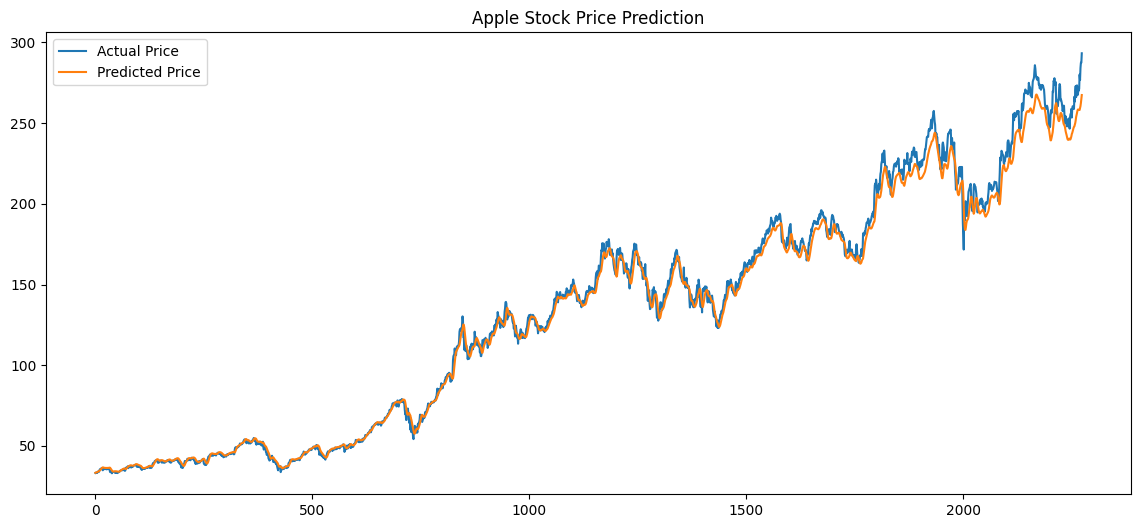

In [23]:
plt.figure(figsize=(14,6))

plt.plot(actual_prices, label="Actual Price")

plt.plot(predictions, label="Predicted Price")

plt.legend()

plt.title("Apple Stock Price Prediction")

plt.show()

In [24]:
last_60_days = scaled_data[-60:]

x_future = []

x_future.append(last_60_days[:,0])

x_future = np.array(x_future)

x_future = np.reshape(x_future, (x_future.shape[0], x_future.shape[1], 1))

In [27]:
future_price = model.predict(x_future)

future_price = scaler.inverse_transform(future_price)

print("Tomorrow Predicted Price:", future_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Tomorrow Predicted Price: 270.1652
